<a href="https://colab.research.google.com/github/sowmiyavetrivel28-git/-PMFBY-District-Crop-Insurance-Analysis-Using-Python_2018-2022-/blob/main/pythonProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Stage 1**


# 🌾 Project Title:
## **PMFBY District-Level Crop Insurance Performance Analysis Using  Python(2018–2022)**

# Dataset Information

- **Source:** India Data Portal / Government of India – PMFBY Data
- **Location:** India (State and District Level)
- **Year/Timeline:** 2018–2022
- **Domain:** Agriculture / Crop Insurance
- **Dataset:** Pradhan Mantri Fasal Bima Yojana (PMFBY)
- **Granularity:** District-Level, Seasonal Data
- **Seasons Covered:** Kharif and Rabi

## Problem Definition

Pradhan Mantri Fasal Bima Yojana (PMFBY) is a crop insurance scheme aimed at providing financial protection to farmers against crop-related risks. This project analyzes district-level PMFBY data from 2018 to 2022 to evaluate farmer participation, seasonal patterns, crop insurance coverage, premium and financial contributions, and demographic participation.

The analysis aims to identify variations in PMFBY performance across states and districts and derive meaningful, data-driven insights that can help understand participation, insurance coverage, and financial contribution patterns under the scheme.

# Objectives

## 1. Participation & Seasonal Analysis

- Analyze PMFBY participation across states and districts from 2018–2022.
- Compare PMFBY participation between Kharif and Rabi seasons.

## 2. Farmer Participation Analysis

- Analyze the participation pattern of Loanee and Non-Loanee farmers.
- Examine gender and farmer-type participation patterns.

## 3. Insurance & Financial Analysis

- Evaluate crop insurance coverage across districts using insured area, insurance units, and sum insured.
- Analyze gross premium and the financial contributions of farmers, State Governments, and the Government of India.

## 4. District Performance Assessment

- Identify high- and low-performing districts based on PMFBY participation, insurance coverage, and financial indicators.

In [ ]:
# Importing Required Libraries

# Data manipulation and analysis
import pandas as pd

# Numerical calculations
import numpy as np

# Data visualization
import matplotlib.pyplot as plt

# Advanced statistical visualization
import seaborn as sns

In [ ]:
#  Loading Data from GITHUB

url ="https://raw.githubusercontent.com/sowmiyavetrivel28-git/-PMFBY-District-Crop-Insurance-Analysis-2018-2022-/main/agri_db.csv"

df = pd.read_csv(url)

df

,id,year,season,scheme,state_name,state_code,district_name,district_code,farmer_count,loanee,...,transgender,sc,st,obc,gen,marginal,small,other,iu_count,gross_premium
0,0,2018,Kharif,PMFBY,Andhra Pradesh,28,Anantapur,502.0,11455,11494.0,...,0.00,6.66,0.44,60.19,32.71,6.32,84.97,8.71,85,1024.79
1,1,2018,Kharif,PMFBY,Andhra Pradesh,28,Chittoor,503.0,22511,23368.0,...,0.06,6.41,0.81,39.90,52.88,16.82,75.32,7.86,614,894.25
2,2,2018,Kharif,PMFBY,Andhra Pradesh,28,East Godavari,505.0,152813,162278.0,...,0.06,4.81,1.34,37.67,56.18,12.82,81.93,5.25,1198,7451.91
3,3,2018,Kharif,PMFBY,Andhra Pradesh,28,Guntur,506.0,18045,18446.0,...,0.08,5.92,0.68,47.91,45.49,23.66,69.20,7.14,402,512.77
4,4,2018,Kharif,PMFBY,Andhra Pradesh,28,Krishna,510.0,77733,83378.0,...,0.04,5.21,0.50,34.74,59.55,31.88,60.80,7.32,836,3686.23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6156,6156,2022,Rabi,WBCIS,Uttarakhand,5,Pithoragarh,53.0,61,20.0,...,0.00,25.70,3.17,9.86,61.27,15.49,84.51,0.00,9,3.03
6157,6157,2022,Rabi,WBCIS,Uttarakhand,5,Rudraprayag,54.0,568,22.0,...,0.00,13.44,0.31,0.31,85.94,4.89,94.66,0.45,4,2.69
6158,6158,2022,Rabi,WBCIS,Uttarakhand,5,Tehri Garhwal,55.0,10220,3153.0,...,0.02,4.24,0.55,59.55,35.66,16.01,82.71,1.28,14,3037.27
6159,6159,2022,Rabi,WBCIS,Uttarakhand,5,Udham Singh Nagar,NaN,141,15.0,...,0.00,9.41,18.82,20.59,51.18,4.12,95.29,0.59,7,4.65


# **INITIAL DATA INSPECTION**

In [ ]:
# take a copy of the dataset:

df_safe=df.copy()

In [ ]:
#View the structure of the dataset

df.shape

(6161, 28)

In [ ]:
# view first few rows

df.head(5)

,id,year,season,scheme,state_name,state_code,district_name,district_code,farmer_count,loanee,...,transgender,sc,st,obc,gen,marginal,small,other,iu_count,gross_premium
0,0,2018,Kharif,PMFBY,Andhra Pradesh,28,Anantapur,502.0,11455,11494.0,...,0.00,6.66,0.44,60.19,32.71,6.32,84.97,8.71,85,1024.79
1,1,2018,Kharif,PMFBY,Andhra Pradesh,28,Chittoor,503.0,22511,23368.0,...,0.06,6.41,0.81,39.90,52.88,16.82,75.32,7.86,614,894.25
2,2,2018,Kharif,PMFBY,Andhra Pradesh,28,East Godavari,505.0,152813,162278.0,...,0.06,4.81,1.34,37.67,56.18,12.82,81.93,5.25,1198,7451.91
3,3,2018,Kharif,PMFBY,Andhra Pradesh,28,Guntur,506.0,18045,18446.0,...,0.08,5.92,0.68,47.91,45.49,23.66,69.20,7.14,402,512.77
4,4,2018,Kharif,PMFBY,Andhra Pradesh,28,Krishna,510.0,77733,83378.0,...,0.04,5.21,0.50,34.74,59.55,31.88,60.80,7.32,836,3686.23


In [ ]:
# Dataset Columns

df.columns

Index(['id', 'year', 'season', 'scheme', 'state_name', 'state_code',
       'district_name', 'district_code', 'farmer_count', 'loanee',
       'non_loanee', 'area_insured', 'sum_insured', 'farmer_share',
       'goi_share', 'state_share', 'male', 'female', 'transgender', 'sc', 'st',
       'obc', 'gen', 'marginal', 'small', 'other', 'iu_count',
       'gross_premium'],
      dtype='object')

In [ ]:
# Dataset Information and Data Types

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6161 entries, 0 to 6160
Data columns (total 28 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             6161 non-null   int64  
 1   year           6161 non-null   int64  
 2   season         6161 non-null   object 
 3   scheme         6161 non-null   object 
 4   state_name     6161 non-null   object 
 5   state_code     6161 non-null   int64  
 6   district_name  6161 non-null   object 
 7   district_code  5422 non-null   float64
 8   farmer_count   6161 non-null   int64  
 9   loanee         6160 non-null   float64
 10  non_loanee     6161 non-null   int64  
 11  area_insured   6161 non-null   float64
 12  sum_insured    6161 non-null   float64
 13  farmer_share   6161 non-null   float64
 14  goi_share      6161 non-null   float64
 15  state_share    6161 non-null   float64
 16  male           6091 non-null   float64
 17  female         6091 non-null   float64
 18  transgen

In [ ]:
#Statistical Summary of Numerical Variables

df.describe()

,id,year,state_code,district_code,farmer_count,loanee,non_loanee,area_insured,sum_insured,farmer_share,...,transgender,sc,st,obc,gen,marginal,small,other,iu_count,gross_premium
count,6161.000000,6161.000000,6161.000000,5422.000000,6.161000e+03,6.160000e+03,6.161000e+03,6161.000000,6161.000000,6161.000000,...,6091.000000,6091.000000,6091.000000,6091.000000,6091.000000,6091.000000,6091.000000,6091.000000,6161.000000,6161.000000
mean,3080.000000,2019.811394,19.093491,353.080044,2.480393e+04,4.164701e+04,1.832689e+04,41.400735,15993.387038,321.786437,...,0.066231,5.777285,10.114815,38.529521,45.578380,21.478861,60.304365,18.216774,228.533355,2255.688911
std,1778.671836,1.426377,9.796734,204.740547,4.736395e+04,1.238617e+05,9.170390e+04,124.914868,32988.035495,705.065074,...,0.539522,7.197323,19.721359,25.163139,29.148505,18.039795,23.586045,20.998843,297.982625,6187.390408
min,0.000000,2018.000000,1.000000,1.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,...,-0.010000,0.000000,0.000000,0.000000,-0.010000,0.000000,0.000000,-0.010000,0.000000,0.000000
25%,1540.000000,2019.000000,9.000000,144.000000,3.120000e+02,1.020000e+02,2.500000e+01,0.150000,86.430000,1.590000,...,0.000000,1.290000,0.150000,15.975000,19.950000,9.210000,46.925000,3.470000,12.000000,8.050000
50%,3080.000000,2020.000000,22.000000,387.000000,5.628000e+03,3.045500e+03,2.950000e+02,4.300000,2554.020000,39.290000,...,0.020000,4.100000,1.190000,38.770000,42.120000,17.030000,60.500000,10.870000,84.000000,202.150000
75%,4620.000000,2021.000000,27.000000,527.000000,2.971500e+04,2.824800e+04,3.165000e+03,30.940000,15099.570000,284.720000,...,0.070000,7.785000,8.650000,58.825000,71.025000,28.495000,78.930000,25.260000,354.000000,1342.230000
max,6160.000000,2022.000000,36.000000,755.000000,1.061490e+06,2.180401e+06,2.062026e+06,3777.400000,535572.470000,8600.320000,...,30.940000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,2492.000000,80103.400000


In [ ]:
# Missing Value Analysis

df.isnull().sum()

,0
id,0
year,0
season,0
scheme,0
state_name,0
state_code,0
district_name,0
district_code,739
farmer_count,0
loanee,1


In [ ]:
# Data Types of Variables

df.dtypes

,0
id,int64
year,int64
season,object
scheme,object
state_name,object
state_code,int64
district_name,object
district_code,float64
farmer_count,int64
loanee,float64


In [ ]:
#checking the duplicate values:

df.duplicated().sum()

np.int64(0)

# **Stage - 2**

Data Cleaning,Data Transformation ,Feature Engineering and Final EDA

Handle duplicates

Handle missing values (impute or drop)

column name rename or dropping unwanted columns

Treat outliers if required(optional)

Convert data types if needed

Data Transformation or Data Wrangling

Final EDA

# **DATA CLEANING**



## **Remove Unnecessary Columns**

In [ ]:
# Remove Unnecessary Columns

df.drop(columns=[
    "state_code",
    "district_code",
    "sc",
    "st",
    "obc",
    "gen"
], inplace=True)

# **Data Cleaning – ID Column**

In [ ]:
#  Check ID Data Type

df["id"].dtype

dtype('int64')

# **Data Cleaning – Year Column**



In [ ]:
#  Check Year Data Type

df["year"].dtype

dtype('int64')

In [ ]:
#  Check Unique Year Values

df["year"].unique()

array([2018, 2019, 2020, 2021, 2022])

In [ ]:
#  Check Year Value Counts

df["year"].value_counts().sort_index()

,count
year,
2018,1498
2019,1385
2020,1137
2021,1063
2022,1078


# **Data Cleaning – Season Column**



In [ ]:
#  Check Unique Season Values

df["season"].unique()

array(['Kharif', 'Rabi'], dtype=object)

In [ ]:
#  Check Season Value Counts

df["season"].value_counts()

,count
season,
Rabi,3103
Kharif,3058


In [ ]:
#  Check Season Data Type

df["season"].dtype

dtype('O')

# **Data Cleaning – Scheme Column**



In [ ]:
# Check Unique Scheme Values

df["scheme"].unique()

array(['PMFBY', 'WBCIS'], dtype=object)

In [ ]:
# Check Scheme Value Counts

df["scheme"].value_counts()

,count
scheme,
PMFBY,4416
WBCIS,1745


In [ ]:
# Check Scheme Data Type

df["scheme"].dtype

dtype('O')

# **Data Cleaning – State Name Column**


In [ ]:
#  Check Unique State Names

df["state_name"].unique()

array(['Andhra Pradesh', 'Assam', 'Chhattisgarh', 'Madhya Pradesh',
       'Karnataka', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh',
       'Jammu And Kashmir', 'Jharkhand', 'Kerala', 'Maharashtra',
       'Odisha', 'Puducherry', 'Rajasthan', 'Tamil Nadu', 'Sikkim',
       'Telangana', 'West Bengal', 'Uttar Pradesh', 'Uttarakhand',
       'Tripura', 'Meghalaya', 'Manipur', 'Andaman And Nicobar Islands'],
      dtype=object)

In [ ]:
#  Check State Name Values Counts

df["state_name"].value_counts()

,count
state_name,
Uttar Pradesh,923
Madhya Pradesh,708
Maharashtra,594
Chhattisgarh,536
Rajasthan,498
Karnataka,330
Tamil Nadu,305
Odisha,297
Assam,277


In [ ]:
# Check State Name Data Type

df["state_name"].dtype

dtype('O')

# **Data Cleaning – District Name Column**



In [ ]:
#  Check Leading and Trailing Spaces

df[df["district_name"].str.strip() != df["district_name"]][
    ["district_name"]
].drop_duplicates()

,district_name


In [ ]:
#  Check Capitalization / Title Case

df[df["district_name"] != df["district_name"].str.title()][
    ["district_name"]
].drop_duplicates()

,district_name


In [ ]:
#  Standardize District Name Format

df["district_name"] = df["district_name"].str.strip()

In [ ]:
#  Check District Name Values Counts

df["district_name"].value_counts()

,count
district_name,
Bilaspur,39
Balrampur,35
Raigarh,31
Pratapgarh,27
Hamirpur,21
...,...
Ri Bhoi,1
South Garo Hills,1
Boudh,1


# **Data Cleaning – Farmer Count Column**



In [ ]:
#  Check Data Type

df["farmer_count"].dtype

dtype('int64')

In [ ]:
# statistical anlaysis of farmer count :

df["farmer_count"].describe()

,farmer_count
count,6.161000e+03
mean,2.480393e+04
std,4.736395e+04
min,0.000000e+00
25%,3.120000e+02
50%,5.628000e+03
75%,2.971500e+04
max,1.061490e+06


# **Data Cleaning – Loanee Column**

In [ ]:
#  Check Data Type

df["loanee"].dtype

dtype('float64')

In [ ]:
#  Identify Missing Loanee Records

df.loc[df["loanee"].isnull(), [
    "state_name", "district_name", "year", "season",
    "farmer_count", "non_loanee"
]]

,state_name,district_name,year,season,farmer_count,non_loanee
1726,Karnataka,Gadag,2019,Kharif,5,5


In [ ]:
#  Impute Missing Loanee Value Using District-Season Median

loanee_median = df[
    (df["district_name"] == "Gadag") &
    (df["season"] == "Kharif")
]["loanee"].median()

df["loanee"] = df["loanee"].fillna(loanee_median)

In [ ]:
# change the datatype of the loanee column to integer

df["loanee"] = df["loanee"].astype(int)

# **Data Cleaning – Non-Loanee Column**

In [ ]:
#  Check Data Type

df["non_loanee"].dtype

dtype('int64')

In [ ]:
# statistical analysis of non_loanee

df["non_loanee"].describe()

,non_loanee
count,6.161000e+03
mean,1.832689e+04
std,9.170390e+04
min,0.000000e+00
25%,2.500000e+01
50%,2.950000e+02
75%,3.165000e+03
max,2.062026e+06


# **Data Cleaning – Area Insured Column**

In [ ]:
#  Check Data Type

df["area_insured"].dtype

dtype('float64')

In [ ]:
#  Check Negative Values

(df["area_insured"] < 0).sum()

np.int64(0)

# **Data Cleaning – Sum Insured Column**

In [ ]:
#  Check Data Type

df["sum_insured"].dtype

dtype('float64')

In [ ]:
#  Check Negative Values

(df["sum_insured"] < 0).sum()

np.int64(0)

# **Data Cleaning – Farmer Share Column**

In [ ]:
# Check Data Type

df["farmer_share"].dtype

dtype('float64')

In [ ]:
#  Check Negative Values

(df["farmer_share"] < 0).sum()

np.int64(0)

# **Data Cleaning – GOI Share Column**

In [ ]:
#  Check Data Type

df["goi_share"].dtype

dtype('float64')

In [ ]:
#  Check Negative Values

(df["goi_share"] < 0).sum()

np.int64(0)

# **Data Cleaning – State Share Column**

In [ ]:
# Check Data Type

df["state_share"].dtype

dtype('float64')

In [ ]:
#  Check Negative Values

(df["state_share"] < 0).sum()

np.int64(0)

# **Data Cleaning – Male Column**

In [ ]:
df["male"] = df_safe["male"]

In [ ]:
# check missing values

df["male"].isnull().sum()

np.int64(70)

In [ ]:
# statistial analysis of Male column

df["male"].describe()

,male
count,6091.000000
mean,85.910186
std,10.709759
min,0.000000
25%,81.920000
50%,88.730000
75%,92.160000
max,100.000000


In [ ]:
#  Hierarchical Imputation for Missing Male Values

df["male"] = df["male"].fillna(
    df.groupby(["district_name", "year", "season"])["male"].transform("median")
)

df["male"] = df["male"].fillna(
    df.groupby(["state_name", "year", "season"])["male"].transform("median")
)

df["male"] = df["male"].fillna(
    df.groupby(["state_name", "season"])["male"].transform("median")
)

df["male"] = df["male"].fillna(
    df.groupby("season")["male"].transform("median")
)

In [ ]:
#  Check Data Type

df["male"].dtype

dtype('float64')

# **Data Cleaning – Female Column**

In [ ]:
# check missing values

df["female"].isnull().sum()

np.int64(70)

In [ ]:
#  statistical analysis of the female column

df["female"].describe()

,female
count,6091.000000
mean,14.023584
std,10.640109
min,0.000000
25%,7.770000
50%,11.200000
75%,18.020000
max,100.000000


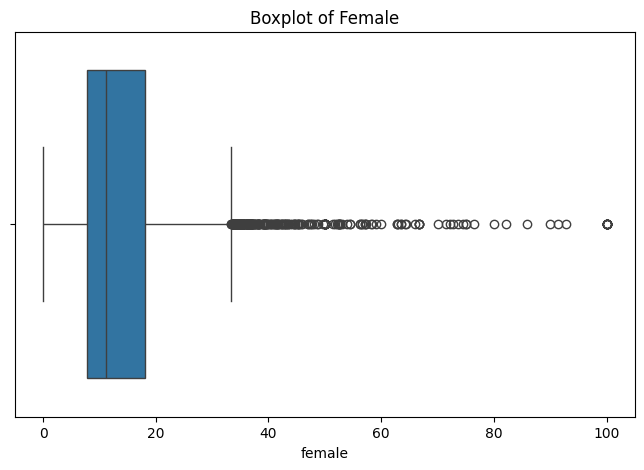

In [ ]:
# Identify Outliers Using Boxplot

plt.figure(figsize=(8, 5))
sns.boxplot(x=df["female"])
plt.title("Boxplot of Female")
plt.show()

In [ ]:
#  Hierarchical Imputation for Missing Female Values

df["female"] = df["female"].fillna(
    df.groupby(["district_name", "year", "season"])["female"].transform("median")
)

df["female"] = df["female"].fillna(
    df.groupby(["state_name", "year", "season"])["female"].transform("median")
)

df["female"] = df["female"].fillna(
    df.groupby(["state_name", "season"])["female"].transform("median")
)

df["female"] = df["female"].fillna(
    df.groupby("season")["female"].transform("median")
)

# **Data Cleaning – Transgender Column**

In [ ]:
# check missing values

df["transgender"].isnull().sum()

np.int64(70)

In [ ]:
df["transgender"].describe()

,transgender
count,6091.000000
mean,0.066231
std,0.539522
min,-0.010000
25%,0.000000
50%,0.020000
75%,0.070000
max,30.940000


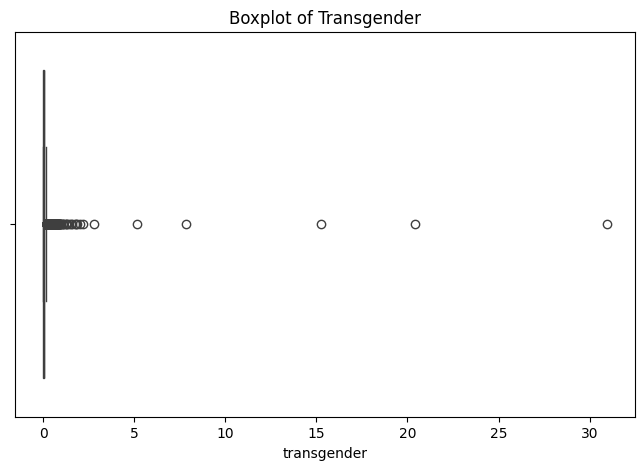

In [ ]:
# Identify Outliers Using Boxplot

plt.figure(figsize=(8, 5))
sns.boxplot(x=df["transgender"])
plt.title("Boxplot of Transgender")
plt.show()

In [ ]:
# Hierarchical Imputation for Missing Transgender Values

df["transgender"] = df["transgender"].fillna(
    df.groupby(["district_name", "year", "season"])["transgender"].transform("median")
)

df["transgender"] = df["transgender"].fillna(
    df.groupby(["state_name", "year", "season"])["transgender"].transform("median")
)



In [ ]:
# Date type check

df["transgender"].dtype

dtype('float64')

# **Data Cleaning – Marginal Column**

In [ ]:
# Check Missing Values

df["marginal"].isnull().sum()

np.int64(70)

In [ ]:
# statistical analysis of marginal column

df["marginal"].describe()

,marginal
count,6091.000000
mean,21.478861
std,18.039795
min,0.000000
25%,9.210000
50%,17.030000
75%,28.495000
max,100.000000


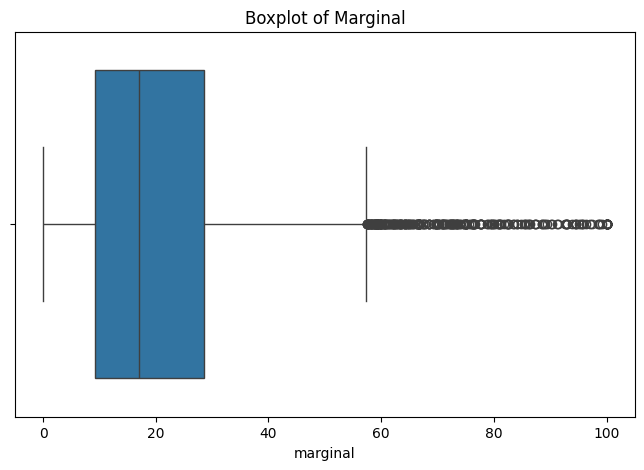

In [ ]:
# Identify Outliers Using Boxplot

plt.figure(figsize=(8, 5))
sns.boxplot(x=df["marginal"])
plt.title("Boxplot of Marginal")
plt.show()

In [ ]:
# Hierarchical Imputation for Missing Marginal Values

df["marginal"] = df["marginal"].fillna(
    df.groupby(["district_name", "year", "season"])["marginal"].transform("median")
)

df["marginal"] = df["marginal"].fillna(
    df.groupby(["state_name", "year", "season"])["marginal"].transform("median")
)

In [ ]:
# Check Data Type

df["marginal"].dtype

dtype('float64')

# **Data Cleaning – Small Column**

In [ ]:
# Check Missing Values

df["small"].isnull().sum()

np.int64(70)

In [ ]:
# statistical analysis of small column

df["small"].describe()

,small
count,6091.000000
mean,60.304365
std,23.586045
min,0.000000
25%,46.925000
50%,60.500000
75%,78.930000
max,100.000000


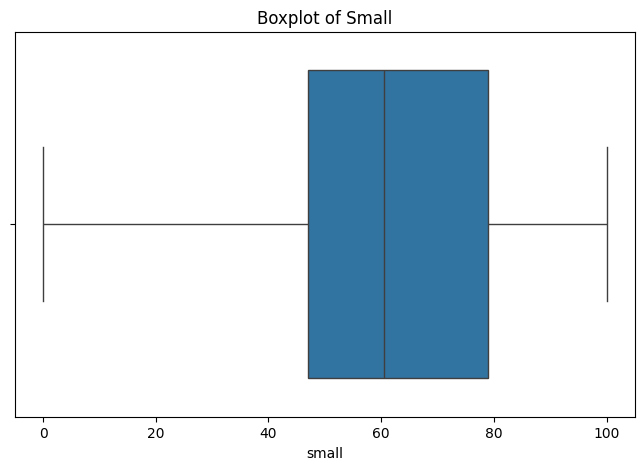

In [ ]:
# Identify Outliers Using Boxplot

plt.figure(figsize=(8, 5))
sns.boxplot(x=df["small"])
plt.title("Boxplot of Small")
plt.show()

In [ ]:
# Hierarchical Imputation for Missing Small Values

df["small"] = df["small"].fillna(
    df.groupby(["district_name", "year", "season"])["small"].transform("median")
)

df["small"] = df["small"].fillna(
    df.groupby(["state_name", "year", "season"])["small"].transform("median")
)

In [ ]:
# Check Data Type

df["small"].dtype

dtype('float64')

# **Data Cleaning – Other Column**

In [ ]:
# Check Missing Values

df["other"].isnull().sum()

np.int64(70)

In [ ]:
# statistical analysis of other column

df["other"].describe()

,other
count,6091.000000
mean,18.216774
std,20.998843
min,-0.010000
25%,3.470000
50%,10.870000
75%,25.260000
max,100.000000


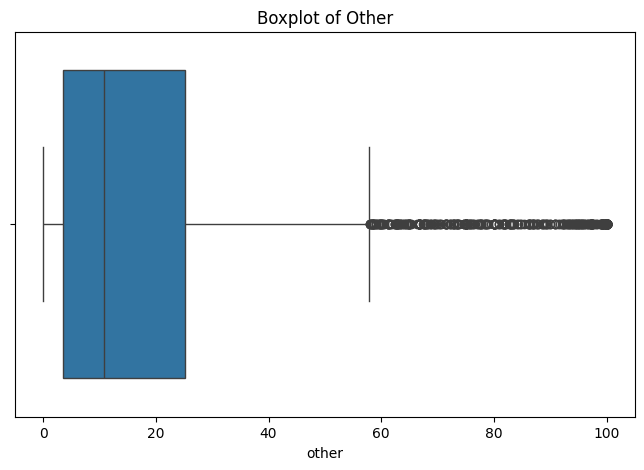

In [ ]:
# Identify Outliers Using Boxplot

plt.figure(figsize=(8, 5))
sns.boxplot(x=df["other"])
plt.title("Boxplot of Other")
plt.show()

In [ ]:
# Hierarchical Imputation for Missing Other Values

df["other"] = df["other"].fillna(
    df.groupby(["district_name", "year", "season"])["other"].transform("median")
)

df["other"] = df["other"].fillna(
    df.groupby(["state_name", "year", "season"])["other"].transform("median")
)

# **Data Cleaning – IU Count Column**

In [ ]:
# Check Data Type

df["iu_count"].dtype

dtype('int64')

In [ ]:
# Check Negative Values

(df["iu_count"] < 0).sum()

np.int64(0)

# **Data Cleaning – Gross Premium Column**

In [ ]:
# Check Data Type

df["gross_premium"].dtype

dtype('float64')

In [ ]:
# Check Negative Values

(df["gross_premium"] < 0).sum()

np.int64(0)

# **🔧 Feature Engineering**

In [ ]:
# 1. Create Total Applications

df["Total_Applications"] = df["loanee"] + df["non_loanee"]

In [ ]:
# 2. Create Total Government Contribution

df["Total_Government_Share"] = df["goi_share"] + df["state_share"]

In [ ]:
# 3. Create Total Premium Contribution

df["Total_Premium_Contribution"] = (
    df["farmer_share"] +
    df["goi_share"] +
    df["state_share"]
)

In [ ]:
# 4. Insurance_Per_Application

df["Insurance_Per_Application"] = (
    df["sum_insured"] / df["Total_Applications"]
)


# **Data Transformation**

## **Rename Columns**

In [ ]:
# Renaming Column Names:

df.rename(columns={
    "id": "ID",
    "year": "Year",
    "season": "Season",
    "scheme": "Scheme",
    "state_name": "State_Name",
    "district_name": "District_Name",
    "farmer_count": "Farmer_Count",
    "loanee": "Loanee",
    "non_loanee": "Non_Loanee",
    "area_insured": "Area_Insured",
    "sum_insured": "Sum_Insured",
    "farmer_share": "Farmer_Share",
    "goi_share": "GOI_Share",
    "state_share": "State_Share",
    "male": "Male",
    "female": "Female",
    "transgender": "Transgender",
    "marginal": "Marginal",
    "small": "Small",
    "other": "Other",
    "iu_count": "Insurance_Unit",
    "gross_premium": "Gross_Premium"
}, inplace=True)

# **FINAL EDA**

In [ ]:
# Check null values:

df.isnull().sum()

,0
ID,0
Year,0
Season,0
Scheme,0
State_Name,0
District_Name,0
Farmer_Count,0
Loanee,0
Non_Loanee,0
Area_Insured,0


In [ ]:
df["Total_Applications"].isnull().sum()

np.int64(0)

In [ ]:
df["Sum_Insured"].isnull().sum()

np.int64(0)

In [ ]:
# Display the null values:

df[df["Total_Applications"] == 0][
    ["Total_Applications", "Sum_Insured", "Insurance_Per_Application"]
]

,Total_Applications,Sum_Insured,Insurance_Per_Application
97,0,0.0,NaN
112,0,0.0,NaN
220,0,0.0,NaN
337,0,0.0,NaN
942,0,0.0,NaN
...,...,...,...
3621,0,0.0,NaN
3622,0,0.0,NaN
3623,0,0.0,NaN
3624,0,0.0,NaN


In [ ]:
# imputing the missing values

df["Insurance_Per_Application"] = df["Insurance_Per_Application"].fillna(0)

In [ ]:
#check null values:

df.isnull().sum()

,0
ID,0
Year,0
Season,0
Scheme,0
State_Name,0
District_Name,0
Farmer_Count,0
Loanee,0
Non_Loanee,0
Area_Insured,0


In [ ]:
# Check Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6161 entries, 0 to 6160
Data columns (total 26 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          6161 non-null   int64  
 1   Year                        6161 non-null   int64  
 2   Season                      6161 non-null   object 
 3   Scheme                      6161 non-null   object 
 4   State_Name                  6161 non-null   object 
 5   District_Name               6161 non-null   object 
 6   Farmer_Count                6161 non-null   int64  
 7   Loanee                      6161 non-null   int64  
 8   Non_Loanee                  6161 non-null   int64  
 9   Area_Insured                6161 non-null   float64
 10  Sum_Insured                 6161 non-null   float64
 11  Farmer_Share                6161 non-null   float64
 12  GOI_Share                   6161 non-null   float64
 13  State_Share                 6161 

In [ ]:
# Display All Columns and Preview Data

pd.set_option("display.max_columns", None)

df.head()

,ID,Year,Season,Scheme,State_Name,District_Name,Farmer_Count,Loanee,Non_Loanee,Area_Insured,Sum_Insured,Farmer_Share,GOI_Share,State_Share,Male,Female,Transgender,Marginal,Small,Other,Insurance_Unit,Gross_Premium,Total_Applications,Total_Government_Share,Total_Premium_Contribution,Insurance_Per_Application
0,0,2018,Kharif,PMFBY,Andhra Pradesh,Anantapur,11455,11494,587,17.44,9493.41,453.87,285.46,285.46,66.56,33.44,0.00,6.32,84.97,8.71,85,1024.79,12081,570.92,1024.79,0.785813
1,1,2018,Kharif,PMFBY,Andhra Pradesh,Chittoor,22511,23368,16,18.82,22410.65,792.39,50.93,50.93,70.52,29.42,0.06,16.82,75.32,7.86,614,894.25,23384,101.86,894.25,0.958375
2,2,2018,Kharif,PMFBY,Andhra Pradesh,East Godavari,152813,162278,3516,97.88,71316.82,1482.17,2984.87,2984.87,64.45,35.49,0.06,12.82,81.93,5.25,1198,7451.91,165794,5969.74,7451.91,0.430153
3,3,2018,Kharif,PMFBY,Andhra Pradesh,Guntur,18045,18446,2044,16.75,12411.11,255.87,128.45,128.45,65.49,34.43,0.08,23.66,69.20,7.14,402,512.77,20490,256.90,512.77,0.605715
4,4,2018,Kharif,PMFBY,Andhra Pradesh,Krishna,77733,83378,215,60.88,56967.44,1196.91,1244.66,1244.66,68.06,31.90,0.04,31.88,60.80,7.32,836,3686.23,83593,2489.32,3686.23,0.681486


# **Stage 3**


# **Statistical analysis & Visualizations**




# **MEASURE OF CENTRAL TENDENCY**

In [ ]:
#Numerical Columns
cols = ["Total_Applications",
    "Area_Insured",
    "Sum_Insured",
    "Gross_Premium"]

In [ ]:
#summary table
summary_table = pd.DataFrame({
    'Mean': df[cols].mean(),
    'Median': df[cols].median(),
    'Mode': df[cols].mode().iloc[0]
})
# Display the table
print("MEASURE OF CENTRAL TENDENCY\n", summary_table)

MEASURE OF CENTRAL TENDENCY
                             Mean   Median  Mode
Total_Applications  59967.745334  7723.00   0.0
Area_Insured           41.400735     4.30   0.0
Sum_Insured         15993.387038  2554.02   0.0
Gross_Premium        2255.688911   202.15   0.0


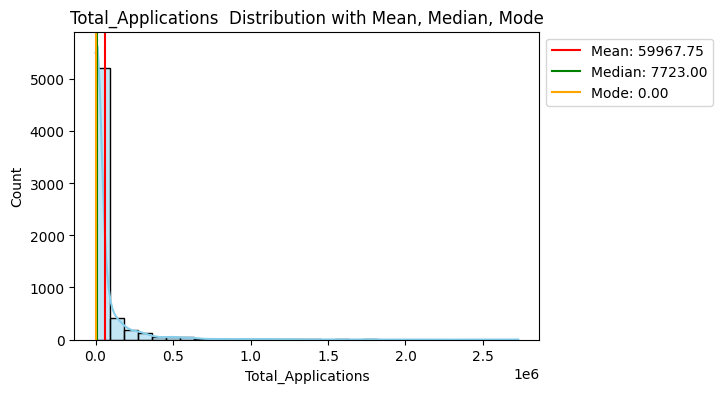

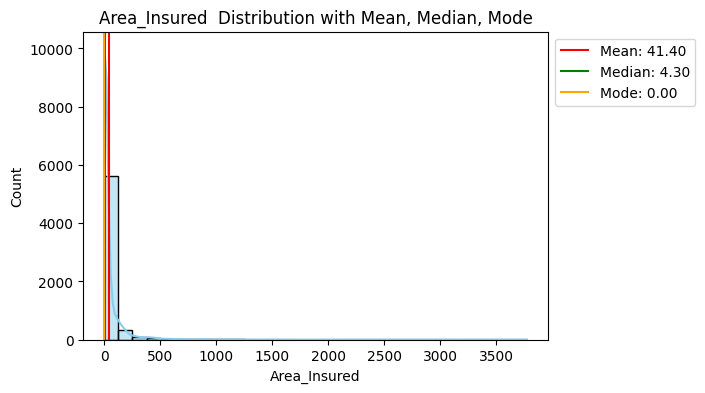

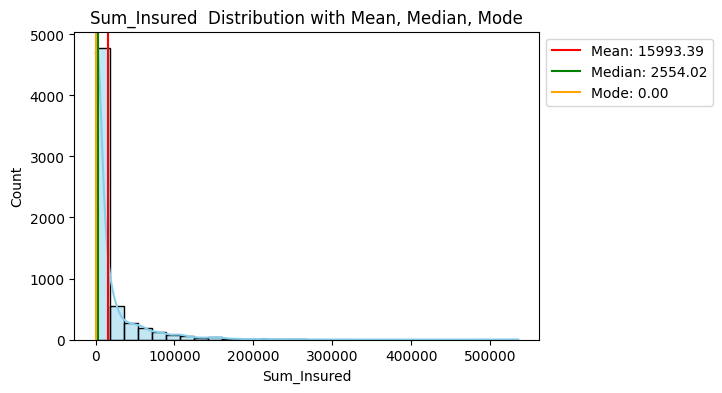

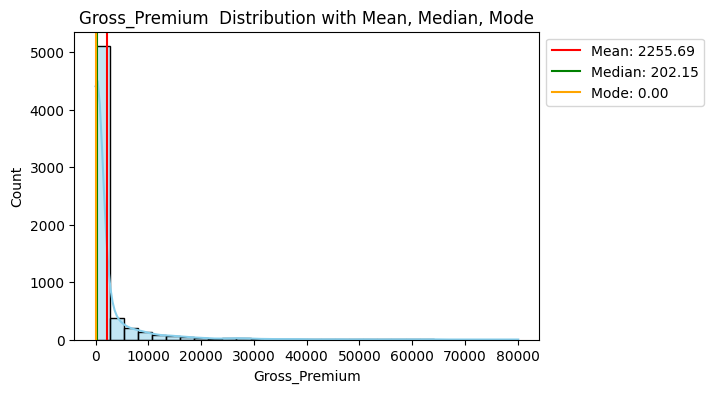

In [ ]:
for col in cols:
    mean_val = summary_table.loc[col, 'Mean']
    median_val = summary_table.loc[col, 'Median']
    mode_val = summary_table.loc[col, 'Mode']

    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True, bins=30, color='skyblue')

    plt.axvline(mean_val, color='red', label=f'Mean: {mean_val:.2f}')
    plt.axvline(median_val, color='green', label=f'Median: {median_val:.2f}')
    plt.axvline(mode_val, color='orange', label=f'Mode: {mode_val:.2f}')

    plt.title(f'{col}  Distribution with Mean, Median, Mode')
    plt.legend(loc='upper left', bbox_to_anchor=(1,1))
    plt.show()

### Interpretation – Measures of Central Tendency

- **Total Applications:** The mean is **59,967.75**, while the median is **7,723.00** and the mode is **0.00**. The large difference between the mean and median indicates a **right-skewed distribution**, with some districts having very high application counts.

- **Area Insured:** The mean is **41.40**, while the median is **4.30** and the mode is **0.00**. The mean being higher than the median indicates a **right-skewed distribution**, with some districts having larger insured areas.

- **Sum Insured:** The mean is **15,993.39**, while the median is **2,554.02** and the mode is **0.00**. The large difference between the mean and median indicates **right skewness**, with some observations having very high insured amounts.

- **Gross Premium:** The mean is **2,255.69**, while the median is **202.15** and the mode is **0.00**. The mean being considerably higher than the median indicates a **right-skewed distribution**, with some observations having very high premium values.

- **Overall:** All four variables show **right-skewed distributions**, with **0.00 as the mode**, meaning zero is the most frequently occurring value in each variable.

# **MEASURE OF DISPERSION**-**Variance and Standard Deviation**


## **VARIANCE**

In [ ]:
# Measure of Dispersion – Variance
variance_table = df[cols].var().to_frame(name='Variance')

print("MEASURE OF DISPERSION: VARIANCE \n")
print(variance_table)

MEASURE OF DISPERSION: VARIANCE 

                        Variance
Total_Applications  2.607710e+10
Area_Insured        1.560372e+04
Sum_Insured         1.088210e+09
Gross_Premium       3.828380e+07


### Interpretation – Measure of Dispersion (Variance)

- **Total Applications:** The variance is **2.607710 × 10¹⁰**, indicating a very high dispersion in farmer participation across districts. This means the application counts are widely spread from the average, with some districts having much higher application counts.

- **Area Insured:** The variance is **1.560372 × 10⁴**, indicating considerable dispersion in insured areas across districts. This suggests that the extent of crop insurance coverage varies across districts.

- **Sum Insured:** The variance is **1.088210 × 10⁹**, indicating substantial dispersion in insured amounts across districts. This shows that the insurance values vary considerably between districts.

- **Gross Premium:** The variance is **3.828380 × 10⁷**, indicating considerable dispersion in gross premium values across districts. This suggests significant variation in premium values between districts.

- **Overall:** All four variables show considerable variation across districts, indicating differences in farmer participation, insurance coverage, insured amounts, and gross premium values.

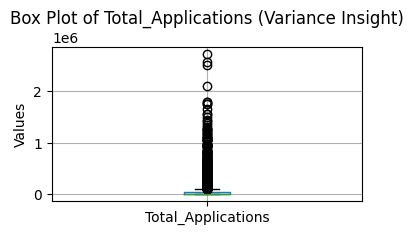

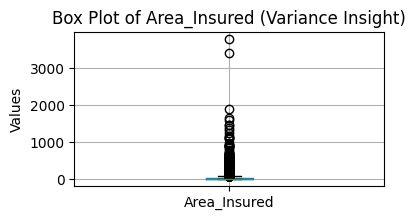

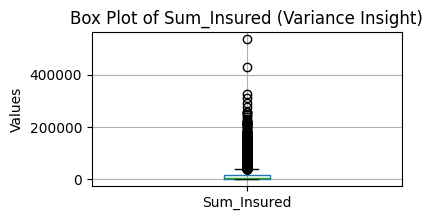

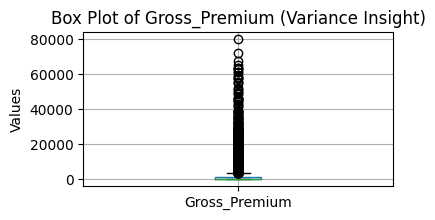

In [ ]:
#box plot for variance

for col in cols:
    plt.figure(figsize=(4, 2))
    df.boxplot(column=col)
    plt.title(f'Box Plot of {col} (Variance Insight)')
    plt.ylabel('Values')
    plt.show()

## **STANDARD DEVIATION**

In [ ]:
# Standard deviation

std_table = df[cols].std().to_frame('STANDARD DEVIATION')

print("MEASURE OF DISPERSION: STANDARD DEVIATION \n")
print(std_table)

MEASURE OF DISPERSION: STANDARD DEVIATION 

                    STANDARD DEVIATION
Total_Applications       161484.046982
Area_Insured                124.914868
Sum_Insured               32988.035495
Gross_Premium              6187.390408


In [ ]:
# Calculate mean for each column
means = df[cols].mean()
# Deviation from mean
deviation = df[cols] - means
deviation

,Total_Applications,Area_Insured,Sum_Insured,Gross_Premium
0,-47886.745334,-23.960735,-6499.977038,-1230.898911
1,-36583.745334,-22.580735,6417.262962,-1361.438911
2,105826.254666,56.479265,55323.432962,5196.221089
3,-39477.745334,-24.650735,-3582.277038,-1742.918911
4,23625.254666,19.479265,40974.052962,1430.541089
...,...,...,...,...
6156,-59683.745334,-40.580735,-15983.177038,-2252.658911
6157,-59312.745334,-40.740735,-15982.367038,-2252.998911
6158,-43137.745334,629.929265,-5520.067038,781.581089
6159,-59797.745334,-39.930735,-15976.197038,-2251.038911


### Interpretation – Measure of Dispersion (Standard Deviation)

- **Total Applications:** The standard deviation is **161,484.05**, indicating a very high spread in farmer participation across districts. This shows that application counts vary widely from the average.

- **Area Insured:** The standard deviation is **124.91**, indicating considerable variation in the insured area across districts. This suggests differences in crop insurance coverage.

- **Sum Insured:** The standard deviation is **32,988.04**, indicating substantial variation in the insured amounts across districts.

- **Gross Premium:** The standard deviation is **6,187.39**, indicating considerable variation in gross premium values across districts.

- **Overall:** The standard deviation values indicate that **PMFBY participation, insurance coverage, insured amounts, and gross premium vary considerably across districts**, with `Total_Applications` showing the largest spread in its original units.

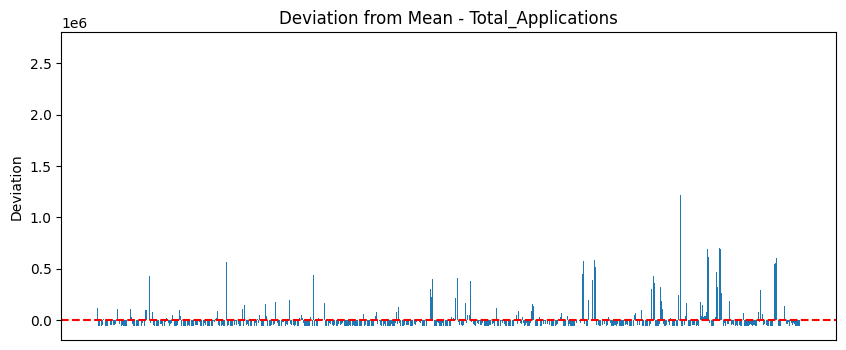

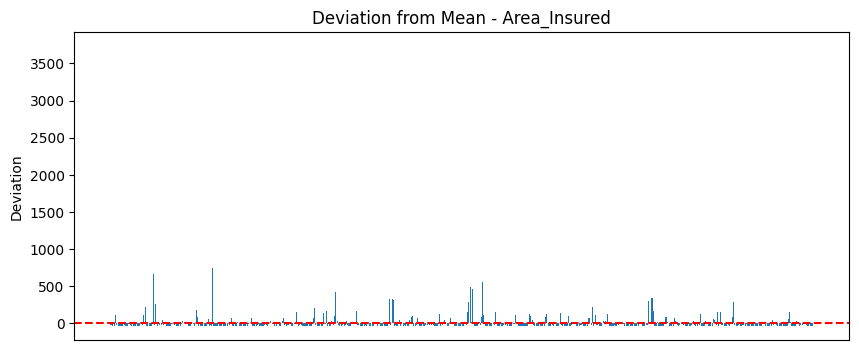

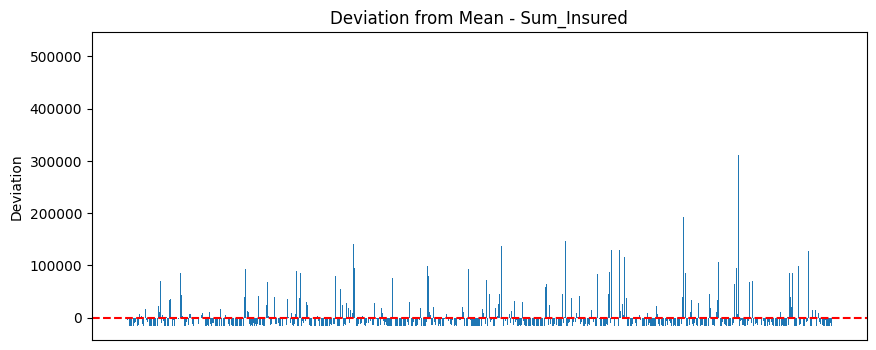

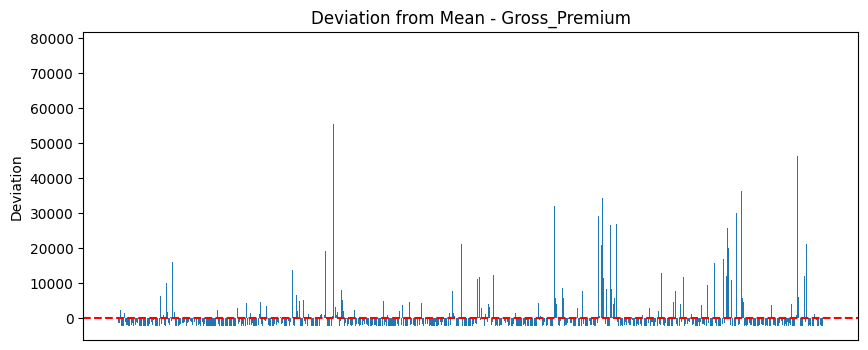

In [ ]:
for col in cols:
    plt.figure(figsize=(10,4))
    plt.bar(range(len(deviation)), deviation[col])
    plt.axhline(0, color='red', linestyle='--')
    plt.title(f'Deviation from Mean - {col}')
    plt.ylabel('Deviation')
    plt.xticks([])
    plt.show()

# **Data visulaization**

## Univariate Analysis

### Objective: To analyse the distribution of Loanee farmer participation

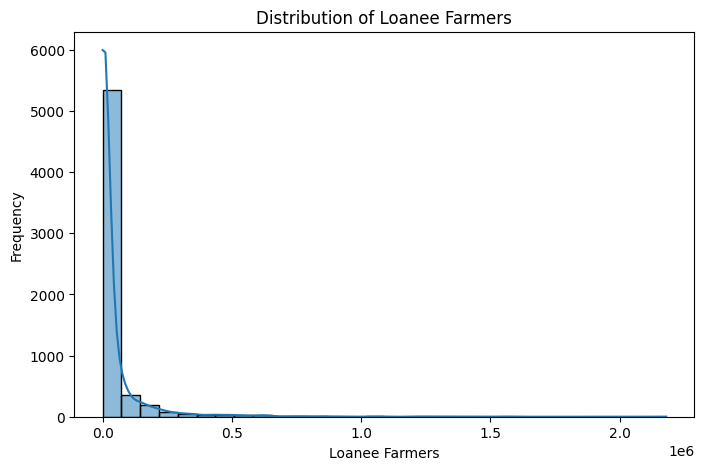

In [ ]:
# Univariate Analysis – Loanee

#Distribution of Loanee Farmer Participation

plt.figure(figsize=(8, 5))

sns.histplot(df["Loanee"], bins=30, kde=True)

plt.title("Distribution of Loanee Farmers")
plt.xlabel("Loanee Farmers")
plt.ylabel("Frequency")
plt.show()

### Interpretation – Loanee Farmer Distribution



- **Key Insight:** Most observations are concentrated in the **lower Loanee participation range**, indicating relatively lower participation in most observations.

- **Pattern:** The distribution has a **long right tail**, showing that a small number of observations have very high Loanee participation.

- **Observation:** The Loanee participation values show **considerable variation** across observations.

- **Distribution:** The histogram is **positively/right-skewed**, meaning most values are at the lower end while a few values are much higher.

- **Overall:** The chart shows that **Loanee farmer participation is unevenly distributed**, with a small number of observations recording exceptionally high participation.

### Objective: To analyse the distribution of Non-Loanee farmer participation

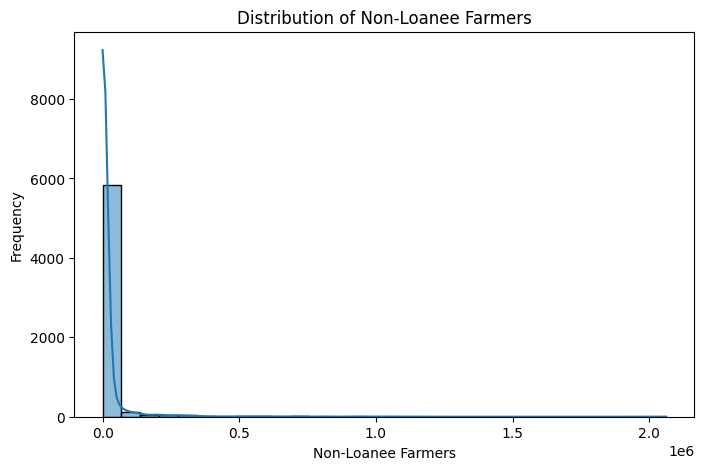

In [ ]:
# Univariate Analysis – Non-Loanee

#Distribution of Non-Loanee Farmer Participation

plt.figure(figsize=(8, 5))

sns.histplot(df["Non_Loanee"], bins=30, kde=True)

plt.title("Distribution of Non-Loanee Farmers")
plt.xlabel("Non-Loanee Farmers")
plt.ylabel("Frequency")
plt.show()

### Interpretation – Non-Loanee Farmer Distribution


- **Key Insight:** Most observations are concentrated in the **lower Non-Loanee participation range**, indicating relatively lower participation in most observations.

- **Pattern:** The distribution has a **long right tail**, showing that a small number of observations have very high Non-Loanee participation.

- **Observation:** Non-Loanee participation shows **considerable variation** across observations.

- **Distribution:** The histogram is **positively/right-skewed**, with most values concentrated near the lower end and a few very high values.

- **Overall:** The chart indicates that **Non-Loanee farmer participation is unevenly distributed**, with a small number of observations recording exceptionally high participation.

### Objective: To understand the distribution of insurance units across the observations

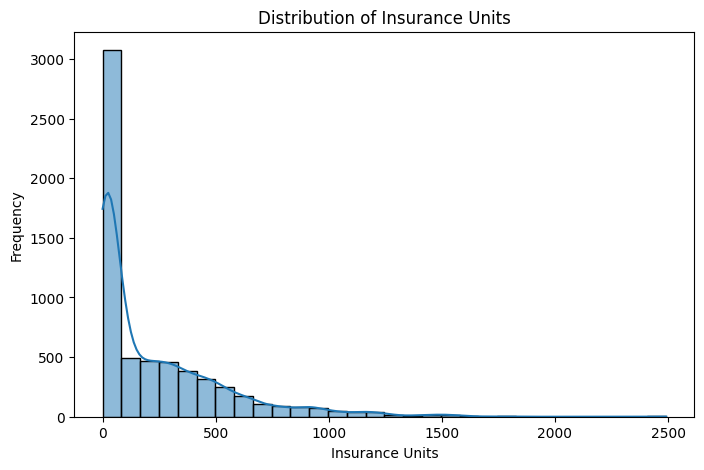

In [ ]:
# Univariate Analysis – Insurance Unit

#Distribution of Insurance Unit Coverage

plt.figure(figsize=(8, 5))

sns.histplot(df["Insurance_Unit"], bins=30, kde=True)

plt.title("Distribution of Insurance Units")
plt.xlabel("Insurance Units")
plt.ylabel("Frequency")
plt.show()

### Interpretation – Insurance Unit Distribution

- **Key Insight:** Most observations are concentrated in the **lower Insurance Unit range**, indicating relatively lower insurance coverage in most observations.

- **Pattern:** The distribution has a **long right tail**, showing that a small number of observations have substantially higher Insurance Unit values.

- **Observation:** Insurance Unit values show **considerable variation** across the observations.

- **Distribution:** The histogram is **positively/right-skewed**, with most values concentrated near the lower end and a few very high values.

- **Overall:** The chart indicates that **Insurance Unit coverage is unevenly distributed**, with a small number of observations recording exceptionally high Insurance Unit values.

## **BIVARIATE ANALYSIS**

### Objective: To analyse the yearly trend in PMFBY participation

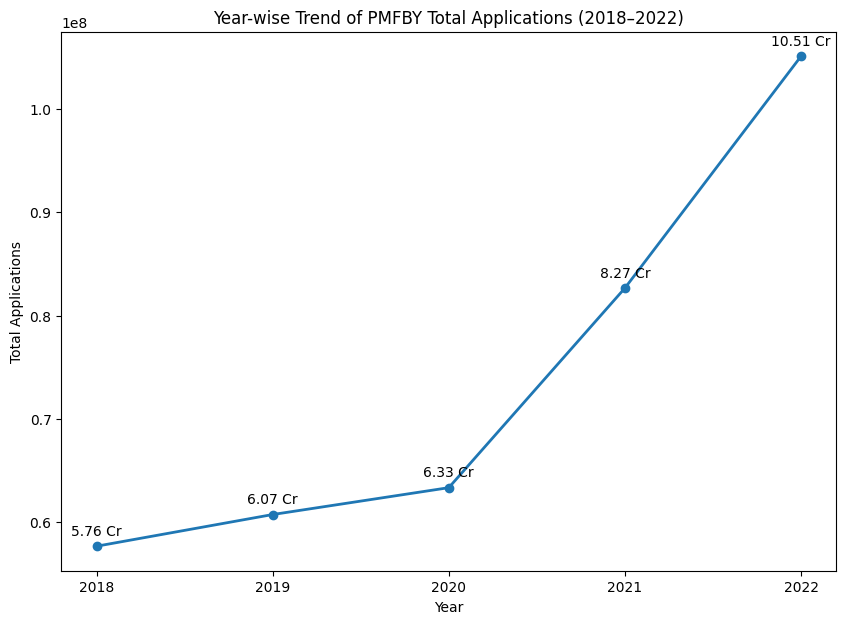

In [ ]:
# Bivariate Analysis – Yearly Participation Trend

# Year-wise Trend of PMFBY Total Applications (2018–2022)

# Calculate year-wise total applications
yearly_applications = (
    df.groupby("Year")["Total_Applications"]
    .sum()
    .reset_index()
)

# Create the line chart
plt.figure(figsize=(10, 7))

plt.plot(
    yearly_applications["Year"],
    yearly_applications["Total_Applications"],
    marker="o",
    linewidth=2
)

# Add data labels in Crores
for x, y in zip(
    yearly_applications["Year"],
    yearly_applications["Total_Applications"]
):
    plt.annotate(
        f"{y / 1e7:.2f} Cr",
        (x, y),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center"
    )

# Set chart title and axis labels
plt.title("Year-wise Trend of PMFBY Total Applications (2018–2022)")
plt.xlabel("Year")
plt.ylabel("Total Applications")
plt.xticks(yearly_applications["Year"])

# Display the chart
plt.show()

### Interpretation – Yearly Trend of Total Applications

- **Key Insight:** Total Applications show a **continuous increasing trend** from 2018 to 2022.

- **Pattern:** Applications increased gradually from **2018 to 2020**, followed by a **much sharper increase in 2021 and 2022**.

- **Observation:** The highest Total Applications were recorded in **2022**, while the lowest were recorded in **2018**.

- **Trend:** The chart indicates a **strong upward trend in PMFBY participation** over the study period.

- **Overall:** PMFBY participation increased substantially between **2018 and 2022**, with the most significant growth occurring during **2020–2022**.

### Objective: To compare PMFBY participation across different seasons

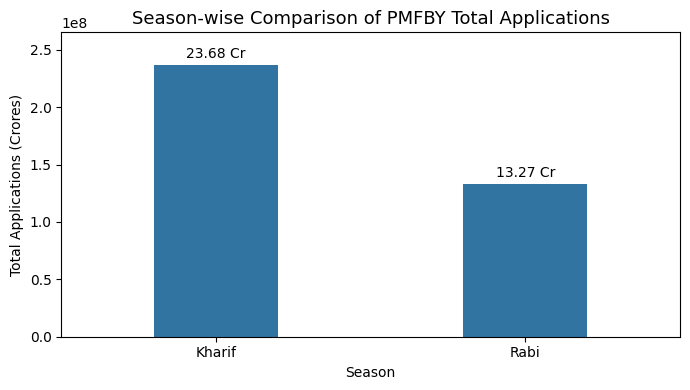

In [ ]:
# Bivariate Analysis – Seasonal Participation

# Calculate season-wise total applications
seasonal = df.groupby("Season")["Total_Applications"].sum()

# Create the bar chart
plt.figure(figsize=(7, 4))

ax = sns.barplot(
    x=seasonal.index,
    y=seasonal.values,
    width=0.4
)

# Add data labels in Crores
for bar, value in zip(ax.patches, seasonal.values):
    ax.annotate(
        f"{value/1e7:.2f} Cr",
        (bar.get_x() + bar.get_width()/2, bar.get_height()),
        ha="center",
        va="bottom",
        xytext=(0, 3),
        textcoords="offset points"
    )

# Set chart title and axis labels
plt.title("Season-wise Comparison of PMFBY Total Applications", fontsize=13)
plt.xlabel("Season")
plt.ylabel("Total Applications (Crores)")

# Format the chart
plt.grid(False)
plt.ylim(0, seasonal.max() * 1.12)
plt.tight_layout()

# Display the chart
plt.show()

### Interpretation – Total Applications by Season

- **Key Insight:** **Kharif recorded approximately 23.5 crore Total Applications**, while **Rabi recorded approximately 13.3 crore Total Applications**, showing substantially higher participation during Kharif.

- **Pattern:** The Kharif bar is considerably taller than the Rabi bar, with a difference of approximately **10.2 crore applications**.

- **Observation:** Kharif participation is approximately **1.8 times** higher than Rabi participation, indicating a strong seasonal difference in PMFBY participation.

- **Overall:** The chart indicates that **Kharif is the more dominant season for PMFBY participation**, while Rabi has comparatively lower participation.

### Objective: To compare Loanee and Non-Loanee farmer participation

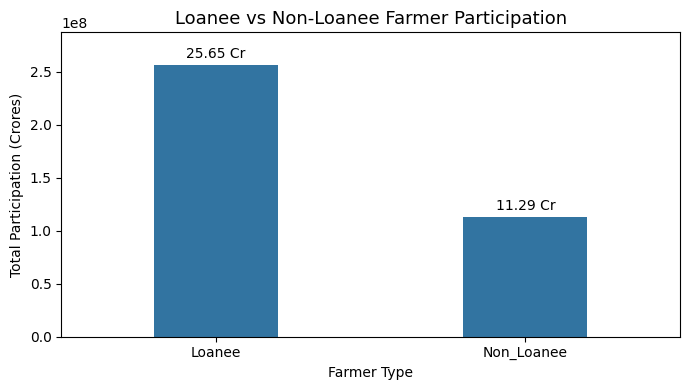

In [ ]:
# Bivariate Analysis – Loanee vs Non-Loanee Participation

# Calculate total Loanee and Non-Loanee participation
farmer_type = df[["Loanee", "Non_Loanee"]].sum()

# Create the bar chart
plt.figure(figsize=(7, 4))

ax = sns.barplot(
    x=farmer_type.index,
    y=farmer_type.values,
    width=0.4
)

# Add data labels in Crores
for bar, value in zip(ax.patches, farmer_type.values):
    ax.annotate(
        f"{value/1e7:.2f} Cr",
        (bar.get_x() + bar.get_width()/2, bar.get_height()),
        ha="center",
        va="bottom",
        xytext=(0, 3),
        textcoords="offset points"
    )

# Set chart title and axis labels
plt.title("Loanee vs Non-Loanee Farmer Participation", fontsize=13)
plt.xlabel("Farmer Type")
plt.ylabel("Total Participation (Crores)")

# Format the chart
plt.grid(False)
plt.ylim(0, farmer_type.max() * 1.12)
plt.tight_layout()

# Display the chart
plt.show()

### Interpretation – Loanee vs Non-Loanee Farmer Participation

- **Key Insight:** **Loanee farmers recorded approximately 25.7 crore participation**, while **Non-Loanee farmers recorded approximately 11.3 crore participation**, showing substantially higher participation among Loanee farmers.

- **Pattern:** The Loanee bar is considerably taller than the Non-Loanee bar, indicating a clear difference in participation between the two groups.

- **Observation:** Loanee participation is approximately **2.3 times** higher than Non-Loanee participation.

- **Overall:** The chart indicates that **Loanee farmers have a significantly higher participation level than Non-Loanee farmers** under PMFBY.

### Objective: To analyse the relationship between Area Insured and Sum Insured

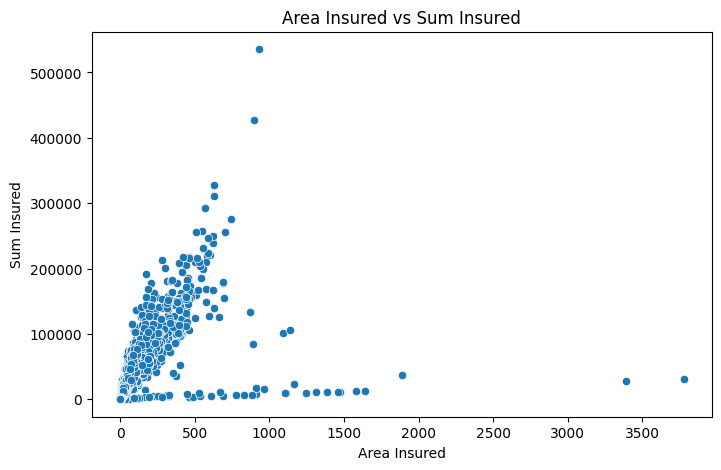

In [ ]:
# Bivariate Analysis – Crop Insurance Coverage Relationship

# Relationship Between Area Insured and Sum Insured

# Create the scatter plot
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Area_Insured",
    y="Sum_Insured"
)

# Set chart title and axis labels
plt.title("Area Insured vs Sum Insured")
plt.xlabel("Area Insured")
plt.ylabel("Sum Insured")

# Display the chart
plt.show()

### Interpretation – Area Insured vs Sum Insured

- **Key Insight:** The scatter plot shows a **positive relationship** between Area Insured and Sum Insured. As the insured area increases, the Sum Insured generally tends to increase.

- **Pattern:** Most observations are concentrated below approximately **800 Area Insured** and **2.5 lakh Sum Insured**, showing that most observations fall within this range.

- **Observation:** A few observations have exceptionally high Sum Insured values, including values above **3 lakh**, with the highest reaching approximately **5.3 lakh**.

- **Variation:** Some observations have relatively high Area Insured but low Sum Insured, indicating that the relationship is **not perfectly consistent** across all observations.

- **Overall:** The chart indicates that **larger insured areas generally correspond to higher Sum Insured**, while the scattered and extreme observations indicate considerable variation in insurance coverage.

## **MULTIVARIATE ANALYSIS**

### Objective: To analyse PMFBY participation by year and season

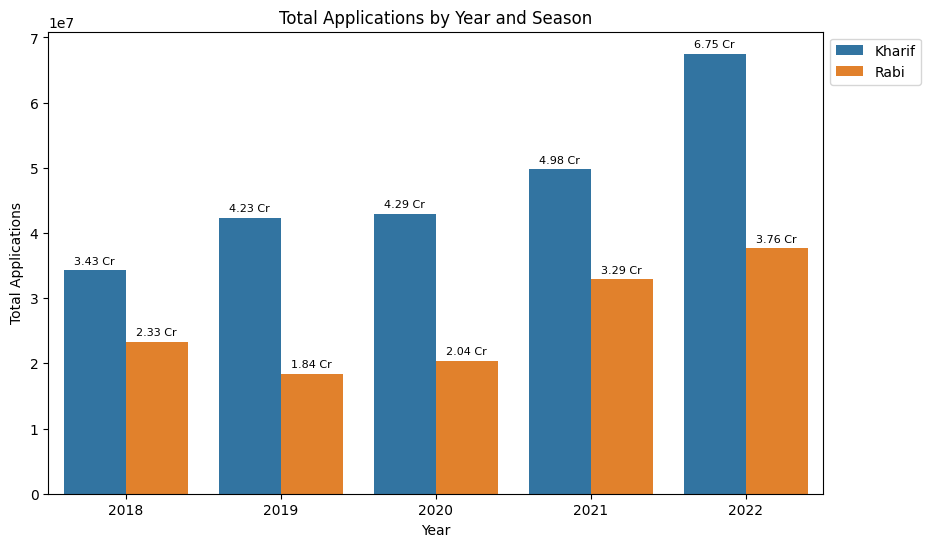

In [ ]:
# Multivariate Analysis – Yearly Seasonal Participation

# Year-wise and Season-wise Trend of PMFBY Applications

# Calculate total applications by year and season
year_season = (
    df.groupby(["Year", "Season"])["Total_Applications"]
    .sum()
    .reset_index()
)

# Create the bar chart
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=year_season,
    x="Year",
    y="Total_Applications",
    hue="Season"
)

# Add data labels in Crores
for container in ax.containers:
    labels = [
        f"{bar.get_height()/1e7:.2f} Cr"
        for bar in container
    ]
    ax.bar_label(container, labels=labels, padding=3, fontsize=8)

# Set chart title and axis labels
plt.title("Total Applications by Year and Season")
plt.xlabel("Year")
plt.ylabel("Total Applications")

# Position the legend outside the chart
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))

# Display the chart
plt.show()

### Interpretation – Yearly and Seasonal Total Applications

- **Key Insight:** **Kharif applications increased from approximately 34.5 crore in 2018 to 67 crore in 2022**, while **Rabi applications increased from approximately 23 crore to 38 crore** during the same period.

- **Pattern:** Kharif participation remained **higher than Rabi in every year** from 2018 to 2022.

- **Trend:** Both Kharif and Rabi show an **overall increasing trend**, with the most noticeable growth occurring between **2020 and 2022**.

- **Observation:** The gap between Kharif and Rabi participation remained substantial throughout the period, with Kharif consistently showing higher participation.

- **Overall:** The chart indicates that **PMFBY participation increased over the years in both seasons, but Kharif remained the dominant season for farmer participation**.

### Objective: To compare state-wise PMFBY participation across years

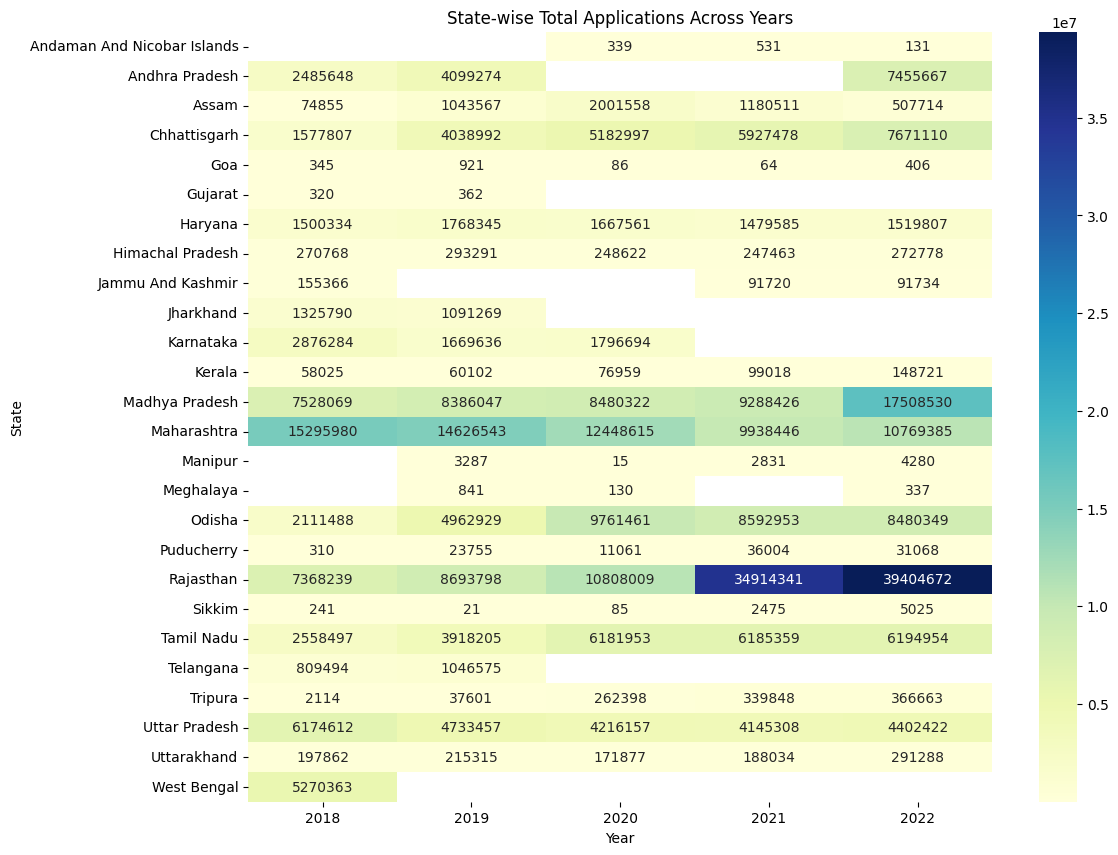

In [ ]:
# Multivariate Analysis – State-wise Participation Across Years

# Create a pivot table for state-wise and year-wise applications
state_year = pd.pivot_table(
    df,
    values="Total_Applications",
    index="State_Name",
    columns="Year",
    aggfunc="sum"
)

# Create the heatmap
plt.figure(figsize=(12, 10))

sns.heatmap(
    state_year,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

# Set chart title and axis labels
plt.title("State-wise Total Applications Across Years")
plt.xlabel("Year")
plt.ylabel("State")

# Display the chart
plt.show()

### Interpretation – State-wise Total Applications Across Years

- **Color Intensity:** Darker shades indicate **higher Total Applications**, while lighter shades indicate lower participation.

- **Key Insight:** **Rajasthan recorded the highest visible participation**, increasing from approximately **7.37 million in 2018** to **39.40 million in 2022**.

- **Pattern:** Rajasthan shows a particularly strong increase in participation during **2021 and 2022**, compared with the earlier years.

- **Observation:** **Madhya Pradesh** also shows strong participation, increasing from approximately **7.53 million in 2018** to **17.51 million in 2022**.

- **Trend:** **Tamil Nadu** shows an overall increasing trend, from approximately **2.56 million in 2018** to **6.19 million in 2022**.

- **Low Participation:** States such as **Goa, Sikkim, Puducherry, and Meghalaya** show comparatively lower Total Applications than the major participating states.

- **Overall:** The heatmap shows **substantial variation in PMFBY participation across states and years**, with **Rajasthan and Madhya Pradesh showing strong participation**, while several smaller states show comparatively lower participation.

### Objective: To identify top-performing districts based on insurance value per application

In [ ]:
# Multivariate Analysis – District Performance

# Calculate district-wise total applications and sum insured
district_performance = (
    df.groupby("District_Name")
    .agg(
        Total_Applications=("Total_Applications", "sum"),
        Sum_Insured=("Sum_Insured", "sum")
    )
    .reset_index()
)

# Calculate insurance value per application
district_performance["Insurance_Per_Application"] = (
    district_performance["Sum_Insured"] /
    district_performance["Total_Applications"]
)

# Sort by insurance value and select the top 10 districts
district_performance = (
    district_performance
    .sort_values("Insurance_Per_Application", ascending=False)
    .head(10)
)

# Display the top 10 district performance table
district_performance

,District_Name,Total_Applications,Sum_Insured,Insurance_Per_Application
412,Nuh,30210,46816.45,1.549700
521,Sirsa,1086597,1219975.82,1.122749
289,Karnal,255562,271354.23,1.061794
176,Fatehabad,550936,576462.55,1.046333
264,Kaithal,382843,399279.44,1.042933
258,Jind,516180,514751.80,0.997233
0,Adilabad,107850,106423.45,0.986773
330,Kurukshetra,250489,246329.94,0.983396
98,Burhanpur,77766,74439.32,0.957222
393,Narayanpet,21918,20525.61,0.936473


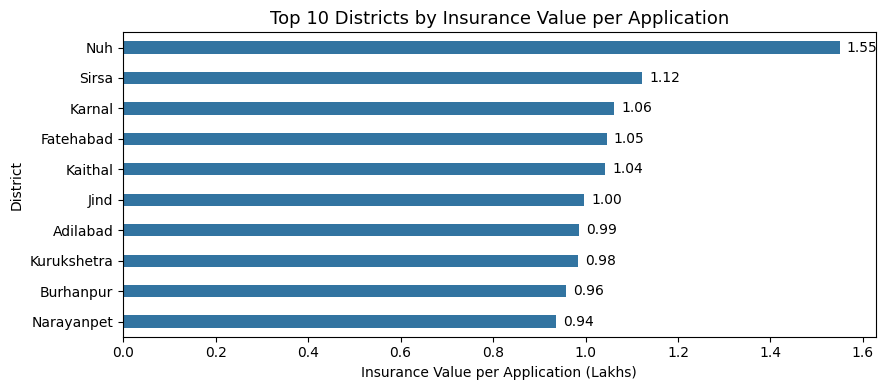

In [ ]:
# Multivariate Analysis – District Performance

# Top 10 Districts By Insurance Value Per Application

# Create the bar chart
plt.figure(figsize=(9, 4))

ax = sns.barplot(
    data=district_performance,
    y="District_Name",
    x="Insurance_Per_Application",
    width=0.4
)

# Add data labels
for bar in ax.patches:
    value = bar.get_width()
    ax.annotate(
        f"{value:.2f}",
        (value, bar.get_y() + bar.get_height() / 2),
        xytext=(5, 0),
        textcoords="offset points",
        va="center"
    )

# Set chart title and axis labels
plt.title(
    "Top 10 Districts by Insurance Value per Application",
    fontsize=13
)
plt.xlabel("Insurance Value per Application (Lakhs)")
plt.ylabel("District")

# Format and display the chart
plt.grid(False)
plt.tight_layout()
plt.show()

### Interpretation – Top 10 Districts by Insurance Value per Application

- **Key Insight:** **Nuh** has the highest Insurance Value per Application at approximately **1.55 lakh**, followed by **Sirsa (1.12 lakh)** and **Karnal (1.06 lakh)**.

- **Pattern:** The Insurance_Per_Application values gradually decrease from **1.55 lakh in Nuh** to **0.94 lakh in Narayanpet**, showing variation among the top 10 districts.

- **Observation:** **Sirsa** has the highest Total Applications (**1,086,597**) among these districts, while **Nuh** has only **30,210 applications** but the highest Insurance_Per_Application (**1.55 lakh**).

- **Comparison:** This shows that a district with a high number of applications does **not necessarily have the highest insurance value per application**.

- **Overall:** The analysis identifies **Nuh as the highest-performing district based on Insurance Value per Application**, while **Narayanpet** has the lowest value at approximately **0.94 lakh** among these top 10 districts.

### Objective: To examine gender-wise farmer participation patterns across years

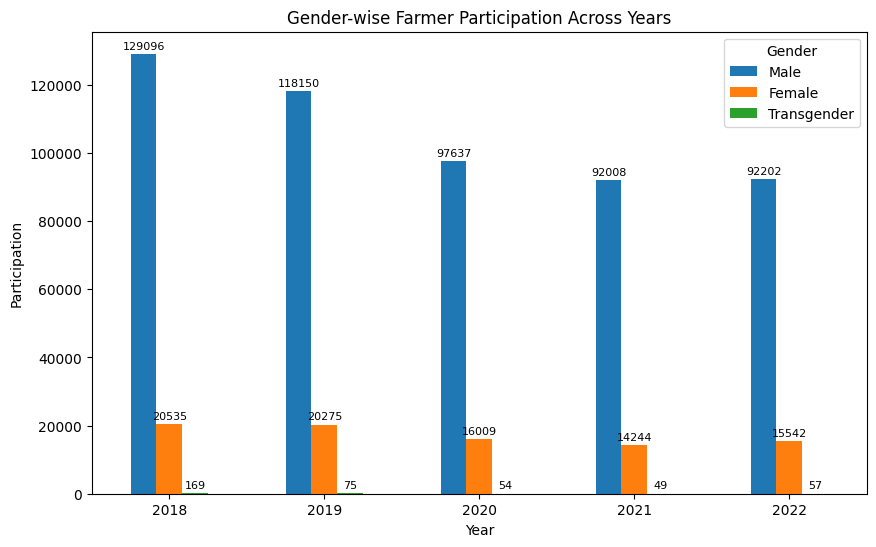

In [ ]:
# Multivariate Analysis – Gender Participation

# Calculate gender-wise participation for each year
gender_year = (
    df.groupby("Year")[["Male", "Female", "Transgender"]]
    .sum()
    .reset_index()
)

# Create the bar chart
ax = gender_year.plot(
    x="Year",
    y=["Male", "Female", "Transgender"],
    kind="bar",
    figsize=(10, 6)
)

# Set chart title and axis labels
plt.title("Gender-wise Farmer Participation Across Years")
plt.xlabel("Year")
plt.ylabel("Participation")
plt.xticks(rotation=0)
plt.legend(title="Gender")

# Add data labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=2, fontsize=8)

# Display the chart
plt.show()

### Objective: To understand the overall gender-wise participation share

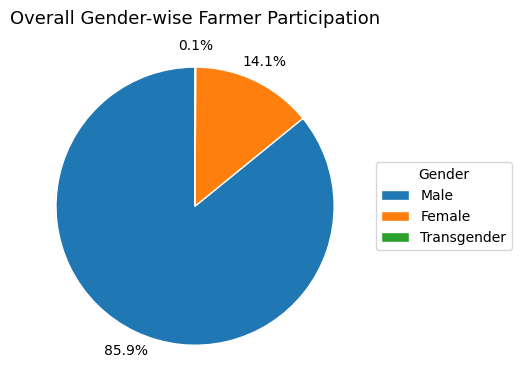

In [ ]:
# Multivariate Analysis – Gender Participation

# Gender-wise Overall Participation

# Calculate total participation for each gender
gender = df[["Male", "Female", "Transgender"]].sum()

# Create the pie chart
plt.figure(figsize=(7, 4))

plt.pie(
    gender.values,
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=1.15,
    wedgeprops={"edgecolor": "white"}
)

# Set chart title
plt.title(
    "Overall Gender-wise Farmer Participation",
    fontsize=13
)

# Place legend outside the chart
plt.legend(
    gender.index,
    title="Gender",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

# Adjust the chart layout
plt.tight_layout()

# Display the chart
plt.show()

### Interpretation – Gender-wise Farmer Participation Across Years

- **Key Insight:** **Male participation is significantly higher than Female and Transgender participation in every year**.

- **Pattern:** Male participation decreased from approximately **129,000 in 2018** to around **92,000 in 2021**, followed by a slight increase to approximately **92,500 in 2022**.

- **Observation:** Female participation was approximately **20,500 in 2018** and remained around **14,000–20,000** during the period, while Transgender participation remained **very low** compared with Male and Female participation.

- **Trend:** Male participation shows an overall decline from 2018 to 2021, with a small recovery in 2022. Female participation also declined initially and showed a slight increase in 2022.

- **Overall:** The chart indicates that **Male farmers are the dominant participant group**, while Female participation is considerably lower and Transgender participation is minimal throughout the study period.

### Objective: To analyse yearly premium contribution and government financial support

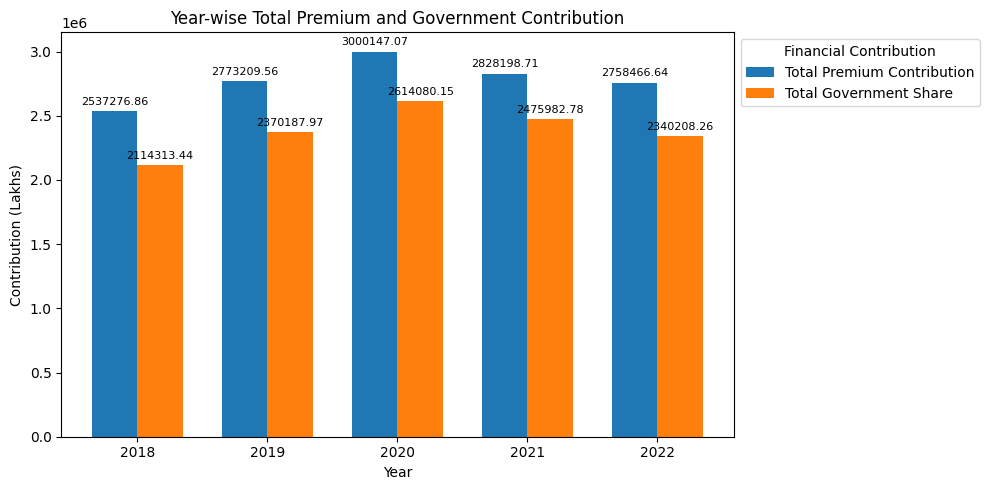

In [ ]:
# Multivariate Analysis – Financial Contributions

# Calculate year-wise total premium and government contribution
financial_analysis = (
    df.groupby("Year")
    .agg(
        Total_Premium_Contribution=("Total_Premium_Contribution", "sum"),
        Total_Government_Share=("Total_Government_Share", "sum")
    )
    .reset_index()
)

# Create the grouped bar chart
plt.figure(figsize=(10, 5))

x = np.arange(len(financial_analysis["Year"]))
width = 0.35

bars1 = plt.bar(
    x - width/2,
    financial_analysis["Total_Premium_Contribution"],
    width,
    label="Total Premium Contribution"
)

bars2 = plt.bar(
    x + width/2,
    financial_analysis["Total_Government_Share"],
    width,
    label="Total Government Share"
)

# Add data labels on bars
plt.bar_label(bars1, fmt="%.2f", padding=3, fontsize=8)
plt.bar_label(bars2, fmt="%.2f", padding=3, fontsize=8)

# Set year labels on X-axis
plt.xticks(x, financial_analysis["Year"])

# Set chart title and axis labels
plt.xlabel("Year")
plt.ylabel("Contribution (Lakhs)")
plt.title("Year-wise Total Premium and Government Contribution")

# Place legend outside the chart
plt.legend(
    title="Financial Contribution",
    loc="upper left",
    bbox_to_anchor=(1, 1)
)

# Remove grid lines
plt.grid(False)

# Adjust the layout
plt.tight_layout()

# Display the chart
plt.show()

### Interpretation – Year-wise Total Premium and Government Contribution

- **Key Insight:** **Total Premium Contribution** is higher than **Total Government Share** in every year, indicating that farmers also contribute a portion of the total premium.

- **Pattern:** Total Premium Contribution increased from approximately **2.54 lakh in 2018** and reached its highest level of around **3.00 lakh in 2020**.

- **Observation:** Total Government Share also increased from approximately **2.11 lakh in 2018** to around **2.62 lakh in 2020**, showing higher government financial support during this period.

- **Trend:** After reaching a peak in **2020**, both Total Premium Contribution and Total Government Share declined in **2021 and 2022**.

- **Comparison:** In **2022**, Total Premium Contribution was approximately **2.76 lakh**, while Total Government Share was approximately **2.34 lakh**, showing that the government continued to provide the major portion of the premium contribution.

- **Overall:** The chart shows that **government contributions form a major part of the total premium contribution**, with both measures reaching their highest levels around **2020** and declining thereafter.

### Objective: To analyse farmer-type participation across years

<Figure size 800x600 with 0 Axes>

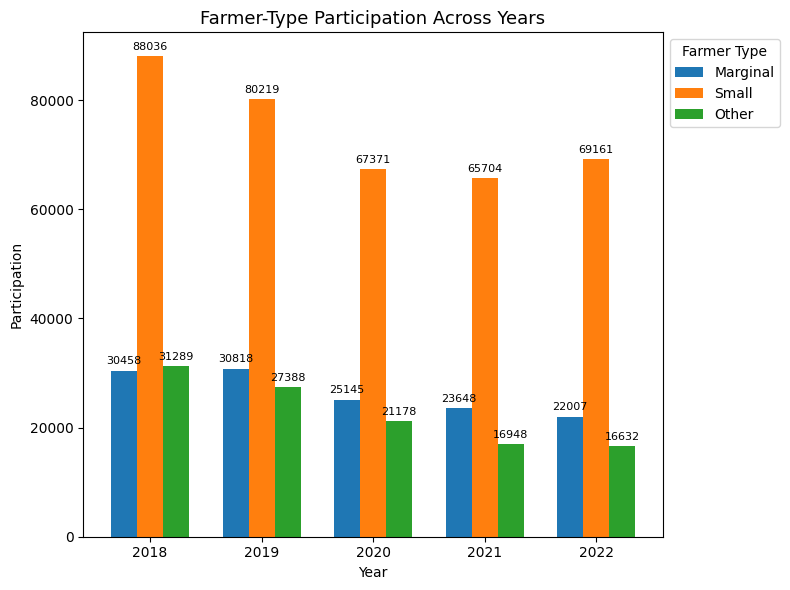

In [ ]:
# Multivariate Analysis – Farmer-Type Participation

# Calculate year-wise participation for each farmer type
farmer_type = (
    df.groupby("Year")[["Marginal", "Small", "Other"]]
    .sum()
)

# Create the bar chart
plt.figure(figsize=(8, 6))

ax = farmer_type.plot(
    kind="bar",
    width=0.7,
    figsize=(8, 6)
)

# Add data labels on bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",
        padding=3,
        fontsize=8
    )

# Set chart title and axis labels
plt.title("Farmer-Type Participation Across Years", fontsize=13)
plt.xlabel("Year")
plt.ylabel("Participation")
plt.xticks(rotation=0)

# Place legend outside the chart
plt.legend(
    title="Farmer Type",
    loc="upper left",
    bbox_to_anchor=(1, 1)
)

# Remove grid lines
plt.grid(False)

# Adjust the chart layout
plt.tight_layout()

# Display the chart
plt.show()

### Interpretation – Farmer-Type Participation Across Years

- **Key Insight:** **Small farmers have the highest participation in every year**, followed by **Marginal farmers**, while **Other farmers have the lowest participation**.

- **Pattern:** Small farmer participation decreased from approximately **88,000 in 2018** to around **66,000 in 2021**, followed by an increase to approximately **69,000 in 2022**.

- **Observation:** Marginal farmer participation also declined from approximately **30,500 in 2018** to around **22,000 in 2022**.

- **Trend:** Other farmer participation showed a continuous decline, from approximately **31,500 in 2018** to around **16,500 in 2022**.

- **Overall:** The chart indicates that **Small farmers are the dominant participating group**, while Marginal and Other farmer participation generally declined over the study period.